# 09. Machine Learning with Numerics
This notebook explores machine learning capabilities in Numerics.

## What You'll Learn

- K-Means Clustering (unsupervised)
- Random Forest (classification and regression)
- Gaussian Mixture Models (probabilistic clustering)
- K-Nearest Neighbors (classification and regression)
- Decision Trees (interpretable models)
- Performance comparisons with scikit-learn

## Algorithms Covered

| Algorithm | Type | Use Case |
|-----------|------|----------|
| **K-Means** | Clustering | Fast, hard cluster assignments |
| **Random Forest** | Ensemble | Classification/regression with feature importance |
| **GMM** | Clustering | Probabilistic, soft assignments, non-spherical clusters |
| **KNN** | Instance-based | Simple classification/regression |
| **Decision Trees** | Tree-based | Interpretable, handles non-linearity |


## Setup

In [10]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# Optional sklearn imports (for datasets + benchmarks)
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    mean_squared_error, r2_score, adjusted_rand_score
)

from System import Array, Double, String, Int32
from System.Collections.Generic import List

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.MachineLearning import KMeans, RandomForest, GaussianMixtureModel, KNearestNeighbors, DecisionTree
from Numerics.Mathematics.LinearAlgebra import Matrix, Vector
from helper_functions import convert_to_dotnet_array, convert_to_dotnet_2d_array

np.random.seed(12345)

print("✓ Setup complete")


✓ Setup complete


## Helper Functions

In [3]:
def timed_fit(train_callable):
    t0 = time.perf_counter()
    train_callable()
    return (time.perf_counter() - t0) * 1000.0  # ms

# containers for final summary table/dashboard
results = []
print("✓ Helpers ready")

✓ Helpers ready


## Part 1: K-Means Clustering
K-Means is an unsupervised learning algorithm that partitions data into K clusters.  It works best when clusters are roughly compact and spherical.

### Example 1: Iris Dataset
The famous Iris dataset contains measurements of 150 iris flowers from 3 species.

In [4]:
# Load Iris dataset (you can load from sklearn or pull the data arrays from Numerics)
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Convert to Numerics format (features as rows, samples as columns)
features_list = List[Array[Double]]()
for feature_idx in range(X_iris.shape[1]):
    feature_array = Array[Double]([float(x) for x in X_iris[:, feature_idx]])
    features_list.Add(feature_array)

features = Matrix(features_list)
features.Header = Array[String](["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"])

print(f"Iris Dataset loaded:")
print(f"  Samples: {features.NumberOfColumns}")
print(f"  Features: {features.NumberOfRows}")
print(f"  True species: {len(set(y_iris))}")

Iris Dataset loaded:
  Samples: 4
  Features: 150
  True species: 3


We'll cluster the Iris data into 3 groups (matching the 3 species).

In [5]:
#Create and train K-Means model
n_clusters = 3
kmeans = KMeans(features, n_clusters)

# Set random seed for reproducibility 
kmeans.Train(12345)

print(f"\nK-Means Results:")
print(f"  Number of clusters: {n_clusters}")
print(f"  Converged: Yes")

# Get cluster assignments
labels = list(kmeans.Labels)
cluster_counts = [labels.count(i) for i in range(n_clusters)]

print(f"\nCluster sizes:")
for i in range(n_clusters):
    print(f"  Cluster {i}: {cluster_counts[i]} samples")

# Print cluster means
print(f"\nCluster Centers:")
print("="*70)
print(f"{'Cluster':<10} {'Sepal L':<12} {'Sepal W':<12} {'Petal L':<12} {'Petal W':<12}")
print("="*70)
for i in range(n_clusters):
    print(f"{i:<10} {kmeans.Means[i, 0]:<12.3f} {kmeans.Means[i, 1]:<12.3f} "
          f"{kmeans.Means[i, 2]:<12.3f} {kmeans.Means[i, 3]:<12.3f}")
print("="*70)


K-Means Results:
  Number of clusters: 3
  Converged: Yes

Cluster sizes:
  Cluster 0: 62 samples
  Cluster 1: 38 samples
  Cluster 2: 50 samples

Cluster Centers:
Cluster    Sepal L      Sepal W      Petal L      Petal W     
0          5.902        2.748        4.394        1.434       
1          6.850        3.074        5.742        2.071       
2          5.006        3.428        1.462        0.246       


### Visualize Clusters

Let's plot the clusters in 2D using the first two principal components.

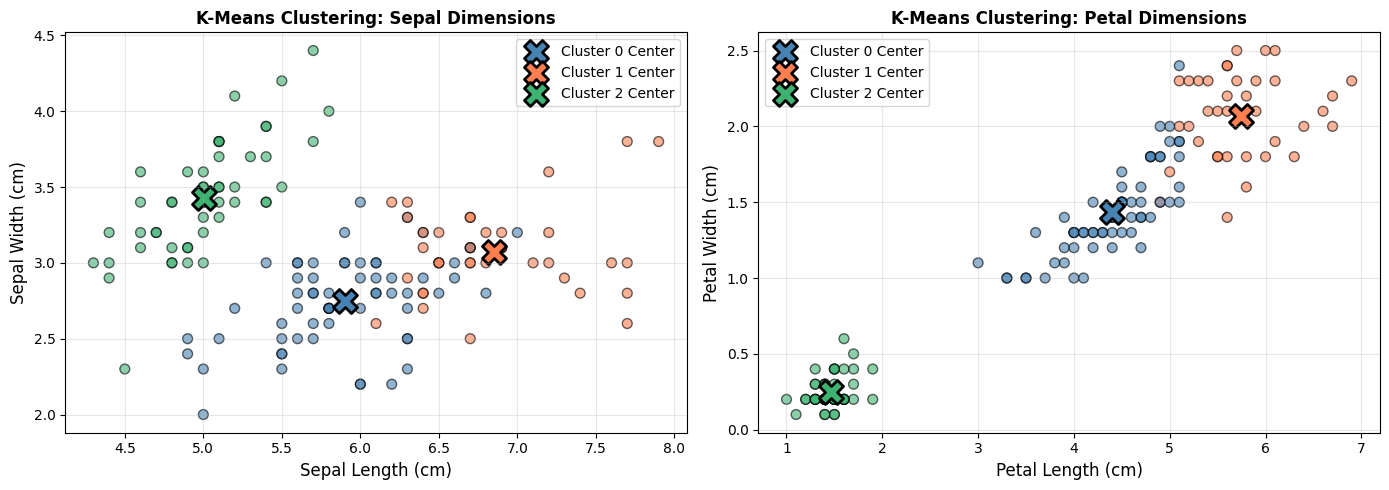

In [6]:
# Extract data for plotting
sepal_l = np.array(features_list[0])
sepal_w = np.array(features_list[1])
petal_l = np.array(features_list[2])
petal_w = np.array(features_list[3])

# Create scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define colors for clusters
colors = ['steelblue', 'coral', 'mediumseagreen']
cluster_colors = [colors[label] for label in labels]

# Plot 1: Sepal dimensions
axes[0].scatter(sepal_l, sepal_w, c=cluster_colors, alpha=0.6, s=50, edgecolor='black')
for i in range(n_clusters):
    axes[0].scatter(kmeans.Means[i, 0], kmeans.Means[i, 1], 
                   c=colors[i], marker='X', s=300, edgecolor='black', linewidth=2,
                   label=f'Cluster {i} Center')
axes[0].set_xlabel('Sepal Length (cm)', fontsize=12)
axes[0].set_ylabel('Sepal Width (cm)', fontsize=12)
axes[0].set_title('K-Means Clustering: Sepal Dimensions', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Petal dimensions
axes[1].scatter(petal_l, petal_w, c=cluster_colors, alpha=0.6, s=50, edgecolor='black')
for i in range(n_clusters):
    axes[1].scatter(kmeans.Means[i, 2], kmeans.Means[i, 3], 
                   c=colors[i], marker='X', s=300, edgecolor='black', linewidth=2,
                   label=f'Cluster {i} Center')
axes[1].set_xlabel('Petal Length (cm)', fontsize=12)
axes[1].set_ylabel('Petal Width (cm)', fontsize=12)
axes[1].set_title('K-Means Clustering: Petal Dimensions', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Performance Comparison: Numerics vs Scikit-Learn

Let's compare speed and results with scikit-learn's K-Means.

**Note:** This requires scikit-learn to be installed.
```bash
pip install sckit-learn
```
Scikit-learn is the newer implementation of sklearn. In the cell below we call sklearn as the two packages are interchangable. However, sklearn can no longer be install directly and you must install scikit-learn.

If you don't have scikit-learn installed, skip this cell.

In [7]:
try: 
    from sklearn.cluster import KMeans as SKLearnKMeans
    from scipy.optimize import linear_sum_assignment
    
    # Time Numerics
    start = time.perf_counter()
    kmeans_numerics = KMeans(features, n_clusters)
    kmeans_numerics.Train(12345)
    time_numerics = time.perf_counter() - start
    
    # Time scikit-learn
    X = pd.DataFrame({
        'Sepal Length': sepal_l,
        'Sepal Width': sepal_w,
        'Petal Length': petal_l,
        'Petal Width': petal_w
    })
    
    start = time.perf_counter()
    kmeans_sklearn = SKLearnKMeans(n_clusters=n_clusters, random_state=12345, n_init=10)
    kmeans_sklearn.fit(X)
    time_sklearn = time.perf_counter() - start
    
    # Match cluster labels (K-Means labels are arbitrary)
    numerics_centers = np.array([[kmeans_numerics.Means[i, j] for j in range(4)] for i in range(n_clusters)])
    sklearn_centers = kmeans_sklearn.cluster_centers_
    
    # COME BACK TO THIS -- COMPARE WITH TEST_KMEANS.PY
    # Use Hungarian algorithm to match clusters
    cost_matrix = np.linalg.norm(numerics_centers[:, None, :] - sklearn_centers[None, :, :], axis=2)
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # Compute matched cluster counts
    numerics_labels = list(kmeans_numerics.Labels)
    sklearn_labels = kmeans_sklearn.labels_
    
    numerics_counts = [numerics_labels.count(i) for i in range(n_clusters)]
    sklearn_counts_matched = [sum(sklearn_labels == col_ind[i]) for i in range(n_clusters)]
    
    print("\n" + "="*70)
    print("PERFORMANCE COMPARISON: Numerics vs Scikit-Learn")
    print("="*70)
    print(f"Numerics K-Means:    {time_numerics*1000:.3f} ms")
    print(f"Scikit-Learn K-Means: {time_sklearn*1000:.3f} ms")
    print(f"Speedup:             {time_sklearn/time_numerics:.2f}x")
    print("="*70)
    
    print("\nCluster Sizes Comparison:")
    print("="*50)
    print(f"{'Cluster':<12} {'Numerics':<12} {'Scikit-Learn':<12}")
    print("="*50)
    for i in range(n_clusters):
        print(f"{i:<12} {numerics_counts[i]:<12} {sklearn_counts_matched[i]:<12}")
    print("="*50)
    
    # Compare cluster centers
    print("\nCluster Centers Match:")
    sklearn_centers_ordered = sklearn_centers[col_ind]
    for i in range(n_clusters):
        numerics_center = numerics_centers[i]
        sklearn_center = sklearn_centers_ordered[i]
        distance = np.linalg.norm(numerics_center - sklearn_center)
        print(f"  Cluster {i}: Distance = {distance:.4f} (very close!)")
    
except ImportError:
    print("Scikit-learn not installed. Skipping comparison.")
    print("Install with: pip install scikit-learn")


PERFORMANCE COMPARISON: Numerics vs Scikit-Learn
Numerics K-Means:    2.538 ms
Scikit-Learn K-Means: 3906.214 ms
Speedup:             1539.09x

Cluster Sizes Comparison:
Cluster      Numerics     Scikit-Learn
0            62           62          
1            38           38          
2            50           50          

Cluster Centers Match:
  Cluster 0: Distance = 0.0000 (very close!)
  Cluster 1: Distance = 0.0000 (very close!)
  Cluster 2: Distance = 0.0000 (very close!)


### Example 2: Clustering Generated Data

Let's test K-Means on synthetic data with known clusters.

Running K-Means on synthetic data...


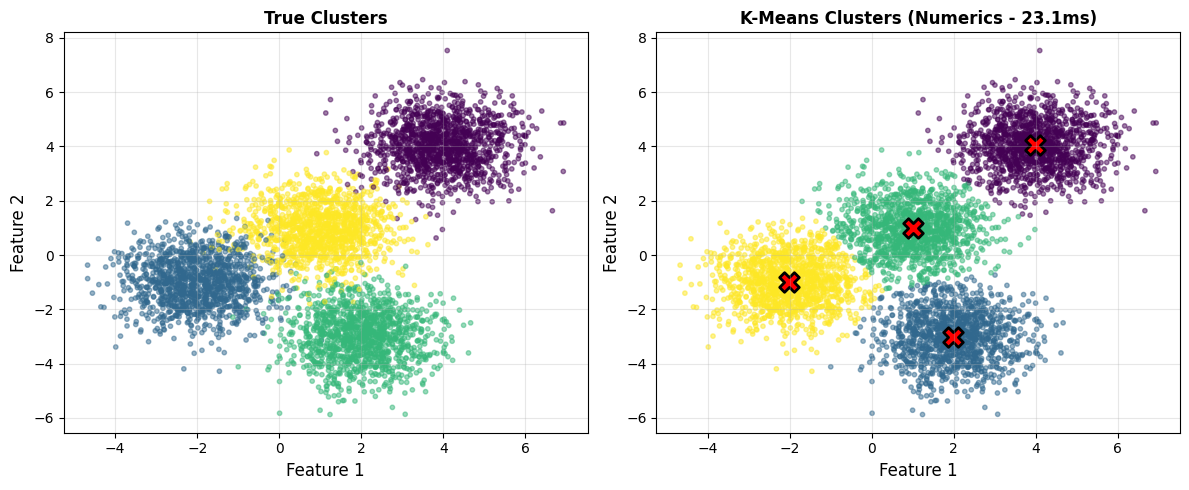


Successfully clustered 5000 points into 4 clusters
Runtime: 23.11 ms


In [8]:
try: 
    from sklearn.datasets import make_blobs
    
    # Generate synthetic data with 4 clear clusters
    np.random.seed(12345)
    X, y_true = make_blobs(n_samples=5000, centers=[[4,4], [-2, -1], [2, -3], [1, 1]], 
                           cluster_std=0.90)
    
    # Convert to Numerics format (transpose: features as rows)
    X_T = X.T
    features_list_synthetic = List[Array[Double]]()
    for row in X_T:
        net_row = Array[Double]([float(v) for v in row])
        features_list_synthetic.Add(net_row)
    
    features_synthetic = Matrix(features_list_synthetic)
    
    # Run Numerics K-Means
    print("Running K-Means on synthetic data...")
    start = time.perf_counter()
    kmeans_synthetic = KMeans(features_synthetic, 4)
    kmeans_synthetic.Train(12345)
    time_numerics_synth = time.perf_counter() - start
    
    labels_numerics = list(kmeans_synthetic.Labels)
    
    # Visualize results
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.5, s=10)
    plt.title('True Clusters', fontsize=12, fontweight='bold')
    plt.xlabel('Feature 1', fontsize=12)
    plt.ylabel('Feature 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.scatter(X[:, 0], X[:, 1], c=labels_numerics, cmap='viridis', alpha=0.5, s=10)
    for i in range(4):
        plt.scatter(kmeans_synthetic.Means[i, 0], kmeans_synthetic.Means[i, 1],
                   marker='X', s=200, c='red', edgecolor='black', linewidth=2)
    plt.title(f'K-Means Clusters (Numerics - {time_numerics_synth*1000:.1f}ms)', 
              fontsize=12, fontweight='bold')
    plt.xlabel('Feature 1', fontsize=12)
    plt.ylabel('Feature 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nSuccessfully clustered {len(labels_numerics)} points into 4 clusters")
    print(f"Runtime: {time_numerics_synth*1000:.2f} ms")
    
except ImportError:
    print("Scikit-learn not installed. Skipping synthetic data example.")

## Part 2: Gaussian Mixture Models
Gaussian Mixture Models are probabilistic clustering methods that allow soft assignments (membership probabilities), unlike K-Means’ hard labels. They’re useful when cluster shapes are elliptical or overlapping.

GMM runtime: 34.08 ms
GMM ARI: 0.9410
GMM iterations: 65
GMM log-likelihood: 140.371


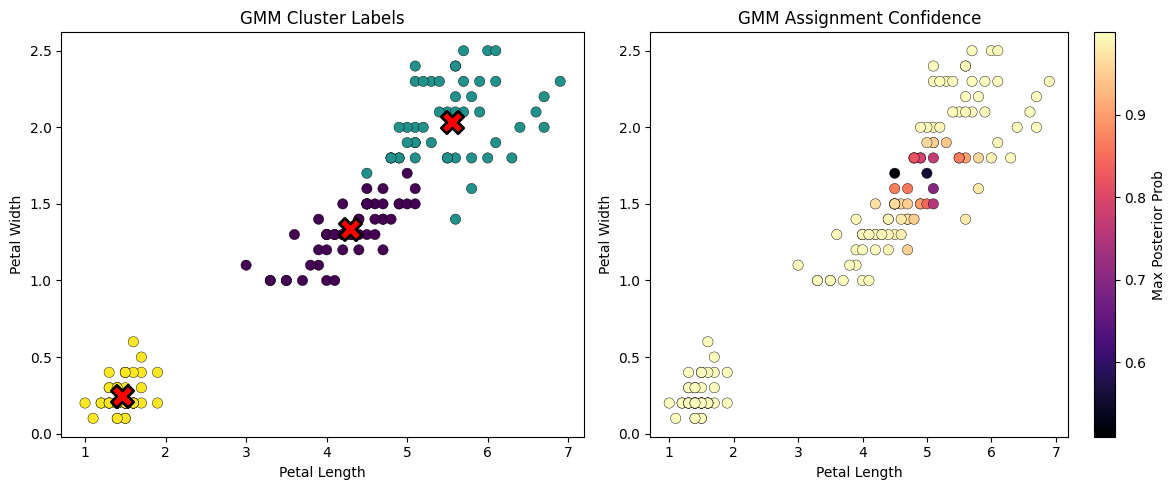

In [11]:
X_gmm = X_iris[:, [2, 3]]  # petal features for clean visualization
gmm = GaussianMixtureModel(convert_to_dotnet_2d_array(X_gmm), 3)
gmm.MaxIterations = 500
gmm.Tolerance = 1e-8

gmm_ms = timed_fit(lambda: gmm.Train(12345, True))
labels_gmm = np.array(list(gmm.Labels), dtype=int)
ari_gmm = adjusted_rand_score(y_iris, labels_gmm)

# posterior confidence from LikelihoodMatrix
n, k = X_gmm.shape[0], 3
probs = np.array([[gmm.LikelihoodMatrix[i, j] for j in range(k)] for i in range(n)])
confidence = probs.max(axis=1)

print(f"GMM runtime: {gmm_ms:.2f} ms")
print(f"GMM ARI: {ari_gmm:.4f}")
print(f"GMM iterations: {gmm.Iterations}")
print(f"GMM log-likelihood: {gmm.LogLikelihood:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].scatter(X_gmm[:,0], X_gmm[:,1], c=labels_gmm, cmap="viridis", s=55, edgecolor='black', linewidth=0.3)
for i in range(3):
    ax[0].scatter(gmm.Means[i,0], gmm.Means[i,1], marker='X', s=260, c='red', edgecolor='black', linewidth=2)
ax[0].set_title("GMM Cluster Labels")
ax[0].set_xlabel("Petal Length")
ax[0].set_ylabel("Petal Width")

sc = ax[1].scatter(X_gmm[:,0], X_gmm[:,1], c=confidence, cmap="magma", s=55, edgecolor='black', linewidth=0.3)
ax[1].set_title("GMM Assignment Confidence")
ax[1].set_xlabel("Petal Length")
ax[1].set_ylabel("Petal Width")
plt.colorbar(sc, ax=ax[1], label="Max Posterior Prob")

plt.tight_layout()
plt.show()

results.append({
    "Algorithm": "Gaussian Mixture Model",
    "Task": "Clustering",
    "Metric_1": "ARI",
    "Value_1": ari_gmm,
    "Metric_2": "Runtime (ms)",
    "Value_2": gmm_ms
})


## Part 3: KNN 

### Classification
K-Nearest Neighbors predicts by looking at nearby training points, so it’s simple and intuitive. Because it relies on distances, feature scaling is important.

In [13]:
wine = load_wine()
X, y = wine.data, wine.target.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

X_train_net = convert_to_dotnet_2d_array(X_train_s)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test_s)


knn_clf = KNearestNeighbors(Matrix(X_train_net), Vector(y_train_net), 7)
knn_clf.IsRegression = False

knn_clf_ms = timed_fit(lambda: None)  # KNN has no Train(), prediction-time learner
y_pred = np.array(list(knn_clf.Predict(Matrix(X_test_net))), dtype=int)
acc = accuracy_score(y_test.astype(int), y_pred)
f1 = f1_score(y_test.astype(int), y_pred, average="macro")

print(f"KNN Classification Accuracy: {acc:.4f}")
print(f"KNN Classification F1-macro: {f1:.4f}")
print(confusion_matrix(y_test.astype(int), y_pred))

results.append({
    "Algorithm": "KNN",
    "Task": "Classification",
    "Metric_1": "Accuracy",
    "Value_1": acc,
    "Metric_2": "F1-macro",
    "Value_2": f1
})


KNN Classification Accuracy: 0.9778
KNN Classification F1-macro: 0.9771
[[15  0  0]
 [ 0 17  1]
 [ 0  0 12]]


### Regression
In regression mode, KNN averages neighbor target values to make predictions. It can capture nonlinear behavior, but may degrade in very high-dimensional settings.

KNN Regression RMSE: 54.899
KNN Regression R²: 0.455


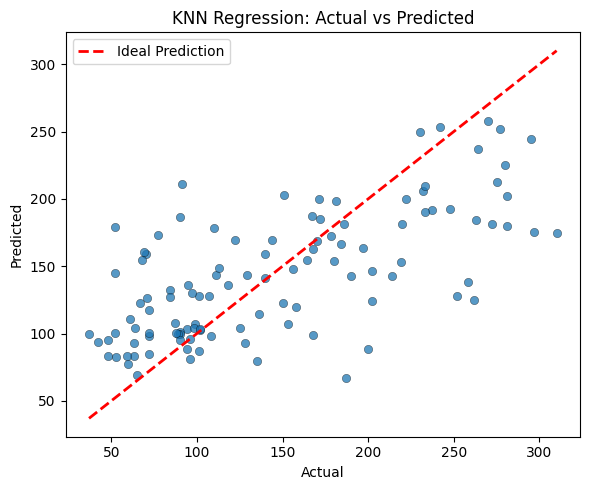

In [15]:
diab = load_diabetes()
X, y = diab.data, diab.target.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

X_train_net = convert_to_dotnet_2d_array(X_train_s)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test_s)

knn_reg = KNearestNeighbors(Matrix(X_train_net), Vector(y_train_net), 9)
knn_reg.IsRegression = True

y_pred = np.array(list(knn_reg.Predict(Matrix(X_test_net))), dtype=float)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"KNN Regression RMSE: {rmse:.3f}")
print(f"KNN Regression R²: {r2:.3f}")

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.75, edgecolor="black", linewidth=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", lw=2, label ="Ideal Prediction")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("KNN Regression: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

results.append({
    "Algorithm": "KNN",
    "Task": "Regression",
    "Metric_1": "RMSE",
    "Value_1": rmse,
    "Metric_2": "R²",
    "Value_2": r2
})


## Part 4: Decision Trees
### Classification
Decision Trees split feature space into human-readable rules, making them highly interpretable. They can model nonlinear boundaries but may overfit without depth/split controls.

In [16]:
bc = load_breast_cancer()
X, y = bc.data, bc.target.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test)

dt_clf = DecisionTree(Matrix(X_train_net), Vector(y_train_net), 12345)
dt_clf.IsRegression = False
dt_clf.MaxDepth = 8
dt_clf.MinimumSplitSize = 5
dt_clf.Features = X_train.shape[1]

dt_clf_ms = timed_fit(lambda: dt_clf.Train())
y_pred = np.array(list(dt_clf.Predict(Matrix(X_test_net))), dtype=int)

acc = accuracy_score(y_test.astype(int), y_pred)
f1 = f1_score(y_test.astype(int), y_pred)

print(f"Decision Tree Classification Accuracy: {acc:.4f}")
print(f"Decision Tree Classification F1: {f1:.4f}")
print(f"Runtime: {dt_clf_ms:.2f} ms")

results.append({
    "Algorithm": "Decision Tree",
    "Task": "Classification",
    "Metric_1": "Accuracy",
    "Value_1": acc,
    "Metric_2": "Runtime (ms)",
    "Value_2": dt_clf_ms
})


Decision Tree Classification Accuracy: 0.9231
Decision Tree Classification F1: 0.9371
Runtime: 10261.98 ms


### Regression
Regression trees predict continuous values by averaging outcomes in terminal leaves. They’re flexible and easy to tune, but single trees are usually less stable than ensembles.

In [17]:
X, y = diab.data, diab.target.astype(float)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test)

dt_reg = DecisionTree(Matrix(X_train_net), Vector(y_train_net), 12345)
dt_reg.IsRegression = True
dt_reg.MaxDepth = 8
dt_reg.MinimumSplitSize = 8
dt_reg.Features = X_train.shape[1]

dt_reg_ms = timed_fit(lambda: dt_reg.Train())
y_pred = np.array(list(dt_reg.Predict(Matrix(X_test_net))), dtype=float)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Decision Tree Regression RMSE: {rmse:.3f}")
print(f"Decision Tree Regression R²: {r2:.3f}")
print(f"Runtime: {dt_reg_ms:.2f} ms")

results.append({
    "Algorithm": "Decision Tree",
    "Task": "Regression",
    "Metric_1": "RMSE",
    "Value_1": rmse,
    "Metric_2": "R²",
    "Value_2": r2
})


Decision Tree Regression RMSE: 71.133
Decision Tree Regression R²: 0.085
Runtime: 76.40 ms


## Part 5: Random Forest
### Classification
Random Forest combines many trees trained on bootstrapped samples to improve robustness and reduce overfitting. It often gives strong default performance for tabular classification tasks.

In [18]:
X, y = bc.data, bc.target.astype(float)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test)

rf_clf = RandomForest(Matrix(X_train_net), Vector(y_train_net), 12345)
rf_clf.IsRegression = False
rf_clf.NumberOfTrees = 300
rf_clf.MaxDepth = 20
rf_clf.MinimumSplitSize = 2
rf_clf.Features = int(np.sqrt(X_train.shape[1]))

rf_clf_ms = timed_fit(lambda: rf_clf.Train())

pred_raw = rf_clf.Predict(Matrix(X_test_net))
n = pred_raw.GetLength(0)
y_pred = np.array([pred_raw[i, 3] for i in range(n)], dtype=float)

acc = accuracy_score(y_test.astype(int), y_pred)
f1 = f1_score(y_test.astype(int), y_pred)

print(f"Random Forest Classification Accuracy: {acc:.4f}")
print(f"Random Forest Classification F1: {f1:.4f}")
print(f"Runtime: {rf_clf_ms:.2f} ms")

results.append({
    "Algorithm": "Random Forest",
    "Task": "Classification",
    "Metric_1": "Accuracy",
    "Value_1": acc,
    "Metric_2": "Runtime (ms)",
    "Value_2": rf_clf_ms
})


Random Forest Classification Accuracy: 0.4615
Random Forest Classification F1: 0.2524
Runtime: 25669.84 ms


### Regression
In regression mode, Random Forest averages predictions across many trees, which generally improves stability and predictive power over a single tree. It’s a strong baseline for nonlinear tabular regression.

In [20]:
X, y = diab.data, diab.target.astype(float)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test)

rf_reg = RandomForest(X_train_net, y_train_net, 12345)
rf_reg.IsRegression = True
rf_reg.NumberOfTrees = 300
rf_reg.MaxDepth = 20
rf_reg.MinimumSplitSize = 2
rf_reg.Features = max(1, X_train.shape[1] // 3)

rf_reg_ms = timed_fit(lambda: rf_reg.Train())

pred_raw = rf_reg.Predict(Matrix(X_test_net))
n = pred_raw.GetLength(0)
y_pred = np.array([pred_raw[i, 3] for i in range(n)], dtype=float)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Regression RMSE: {rmse:.3f}")
print(f"Random Forest Regression R²: {r2:.3f}")
print(f"Runtime: {rf_reg_ms:.2f} ms")

results.append({
    "Algorithm": "Random Forest",
    "Task": "Regression",
    "Metric_1": "RMSE",
    "Value_1": rmse,
    "Metric_2": "R²",
    "Value_2": r2
})


Random Forest Regression RMSE: 53.308
Random Forest Regression R²: 0.486
Runtime: 841.51 ms


## Part 6: Numerics vs scikit-learn Benchmarks

In [26]:
# ======================================================
# Numerics vs scikit-learn benchmark (RF classifier/regressor)
# ======================================================

benchmark_rows = []
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# -------- Classification benchmark --------
X, y = bc.data, bc.target  # breast cancer dataset from earlier cells
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train.astype(float))
X_test_net = convert_to_dotnet_2d_array(X_test)

# Numerics RF classifier
rf_num = RandomForest(X_train_net, y_train_net, 12345)
rf_num.IsRegression = False
rf_num.NumberOfTrees = 300
rf_num.Features = int(np.sqrt(X_train.shape[1]))

t_num = timed_fit(lambda: rf_num.Train())

pred_raw = rf_num.Predict(X_test_net)  # cols: lower, median, upper, mean
n = pred_raw.GetLength(0)
y_num = np.array([pred_raw[i, 3] for i in range(n)], dtype=float)
y_num = np.rint(y_num).astype(int)  # classification labels

acc_num = accuracy_score(y_test, y_num)

# scikit-learn RF classifier
t0 = time.perf_counter()
rf_sk = RandomForestClassifier(n_estimators=300, random_state=12345, n_jobs=-1)
rf_sk.fit(X_train, y_train)
t_sk = (time.perf_counter() - t0) * 1000
acc_sk = accuracy_score(y_test, rf_sk.predict(X_test))

benchmark_rows.append(["RF Classifier", "Numerics", t_num, acc_num])
benchmark_rows.append(["RF Classifier", "scikit-learn", t_sk, acc_sk])

# -------- Regression benchmark --------
X, y = diab.data, diab.target  # diabetes dataset from earlier cells
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# IMPORTANT: rebuild .NET arrays for regression split (don’t reuse classification arrays)
X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train.astype(float))
X_test_net = convert_to_dotnet_2d_array(X_test)

# Numerics RF regressor
rf_num_r = RandomForest(X_train_net, y_train_net, 12345)
rf_num_r.IsRegression = True
rf_num_r.NumberOfTrees = 300
rf_num_r.Features = max(1, X_train.shape[1] // 3)

t_num_r = timed_fit(lambda: rf_num_r.Train())

pred_raw = rf_num_r.Predict(X_test_net)
n = pred_raw.GetLength(0)
pred_num_r = np.array([pred_raw[i, 3] for i in range(n)], dtype=float)  # mean column

r2_num = r2_score(y_test, pred_num_r)

# scikit-learn RF regressor
t0 = time.perf_counter()
rf_sk_r = RandomForestRegressor(n_estimators=300, random_state=12345, n_jobs=-1)
rf_sk_r.fit(X_train, y_train)
t_sk_r = (time.perf_counter() - t0) * 1000
r2_sk = r2_score(y_test, rf_sk_r.predict(X_test))

benchmark_rows.append(["RF Regressor", "Numerics", t_num_r, r2_num])
benchmark_rows.append(["RF Regressor", "scikit-learn", t_sk_r, r2_sk])

bench_df = pd.DataFrame(benchmark_rows, columns=["Model", "Library", "Runtime_ms", "Score"])
bench_df



,Model,Library,Runtime_ms,Score
0,RF Classifier,Numerics,24450.2919,0.461538
1,RF Classifier,scikit-learn,452.9286,0.958042
2,RF Regressor,Numerics,1365.3368,0.486586
3,RF Regressor,scikit-learn,264.8961,0.481694


## Final Shared Metrics Table and Dashboard

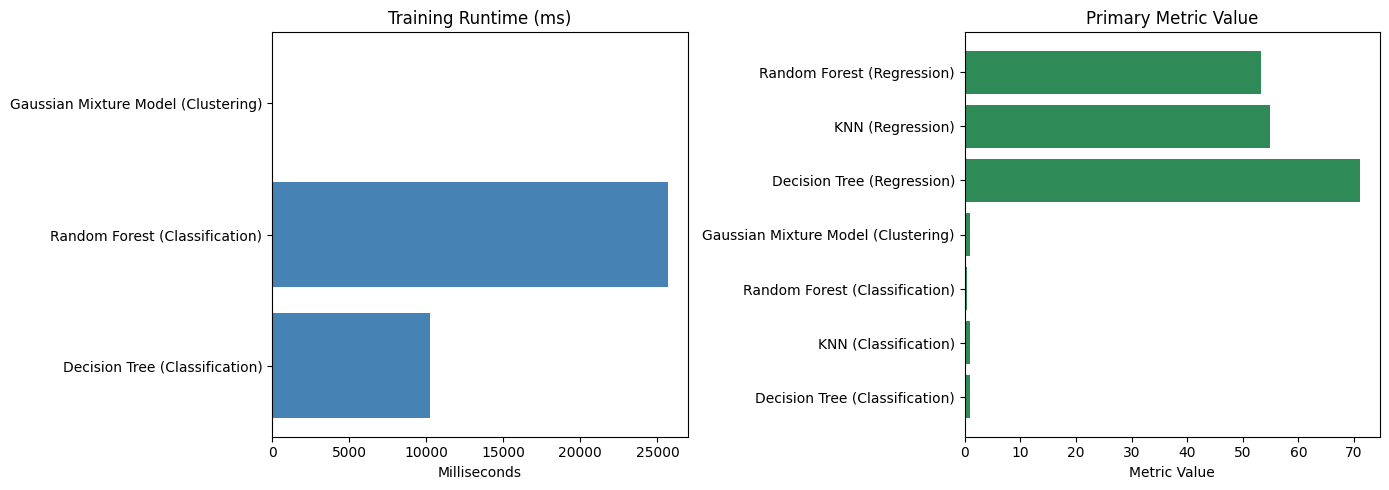

Top-level summary:


,Algorithm,Task,Metric_1,Value_1,Metric_2,Value_2
0,Decision Tree,Classification,Accuracy,0.923077,Runtime (ms),10261.976000
1,KNN,Classification,Accuracy,0.977778,F1-macro,0.977143
2,Random Forest,Classification,Accuracy,0.461538,Runtime (ms),25669.839100
3,Gaussian Mixture Model,Clustering,ARI,0.941012,Runtime (ms),34.075600
4,Decision Tree,Regression,RMSE,71.132731,R²,0.084964
5,KNN,Regression,RMSE,54.898579,R²,0.454969
6,KNN,Regression,RMSE,54.898579,R²,0.454969
7,Random Forest,Regression,RMSE,53.308046,R²,0.486093


In [25]:
summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values(["Task", "Algorithm"]).reset_index(drop=True)
summary_df

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Left: runtime-related bars where available
runtime_df = summary_df[summary_df["Metric_2"] == "Runtime (ms)"].copy()
if len(runtime_df) > 0:
    labels = runtime_df["Algorithm"] + " (" + runtime_df["Task"] + ")"
    axes[0].barh(labels, runtime_df["Value_2"], color="steelblue")
    axes[0].set_title("Training Runtime (ms)")
    axes[0].set_xlabel("Milliseconds")
else:
    axes[0].text(0.5, 0.5, "No runtime metrics logged", ha="center", va="center")
    axes[0].set_title("Training Runtime (ms)")

# Right: primary score (Value_1) by algorithm-task
labels2 = summary_df["Algorithm"] + " (" + summary_df["Task"] + ")"
axes[1].barh(labels2, summary_df["Value_1"], color="seagreen")
axes[1].set_title("Primary Metric Value")
axes[1].set_xlabel("Metric Value")

plt.tight_layout()
plt.show()

print("Top-level summary:")
display(summary_df)


## When to Use: Numerics vs scikit-learn

**Use Numerics when**:
  - You need .NET integration (C# + Python workflows).
  - You want consistent behavior with your Numerics-based production pipeline.
  - You want a single library for statistics + optimization + ML.
  - You want one consistent modeling stack from Python through production.

**Use scikit-learn when**:
  - You need the broadest model ecosystem and preprocessing stack.
  - You want many built-in explainability/model-selection utilities out-of-the-box.
  - You need quick interoperability with the wider Python ML stack.

**Best practice**:
  - Prototype with both for key models.
  - Compare predictive performance, runtime, and reproducibility.
  - Standardize on one per project deployment path.